In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import mpl_toolkits.mplot3d.art3d as patches3d
from matplotlib.path import Path
from matplotlib import animation
from multiprocessing import Process
import numpy as np
import re
import imageio

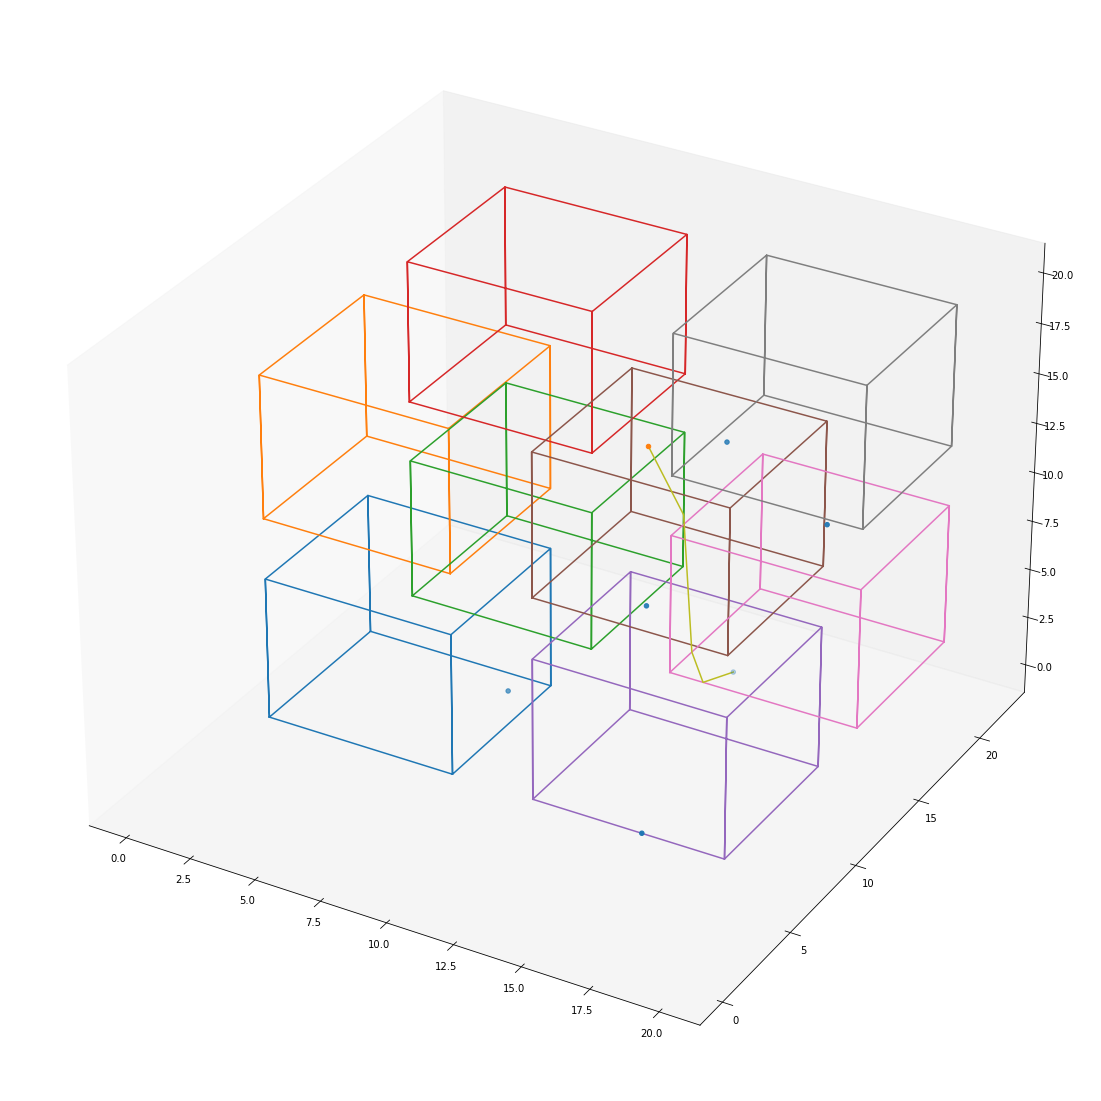

In [2]:
fig, ax = plt.subplots(figsize=(20, 20), subplot_kw={"projection":"3d"})
site_list = []
box_list = []
pth = []

with open('output_fix.txt', mode='r') as output:
    mode = 'b'
    dim = 2
    pattern = re.compile(r'[-+]?(?:\d*\.*\d+)')
    lines = output.readlines()
    index = 0
    xs = []
    ys = []
    zs = []
    
    while index < len(lines):
        n,m,d = map(int, lines[index].split())
        index += 1
        for i in range(n):
            coord = list(map(float, lines[index+i].split()))
            site_list.append(coord)
            xs.append(coord[0])
            ys.append(coord[1])
            zs.append(coord[2])
        index += n
        for i in range(m):
            box = []
            for j in range(2):
                coord = list(map(int, lines[index+j].split()))
                xs.append(float(coord[0]))
                ys.append(float(coord[1]))
                zs.append(float(coord[2]))
                box.append(coord)
            box_list.append(box)
            index += 2
        query = list(map(float,lines[index].split()))
        xs.append(query[0])
        ys.append(query[1])
        zs.append(query[2])
        index += 1
        l = int(lines[index])
        index += 1
        for i in range(l):
            coord = list(map(float, lines[index+i].split()))
            xs.append(coord[0])
            ys.append(coord[1])
            zs.append(coord[2])
            pth.append(coord)
        index += l
X=np.array([0,max(xs)])
Y=np.array([0,max(ys)])
Z=np.array([0,max(zs)])
plt.plot(X,Y,Z,color='None')
x_list, y_list, z_list = zip(*site_list)
ax.scatter(x_list,y_list,z_list)
ax.scatter(query[0],query[1],query[2])

for box in box_list:
    boxx = [box[0][0],box[1][0],box[1][0],box[0][0],box[0][0],box[0][0],box[1][0],box[1][0],box[1][0],box[1][0],box[1][0],box[1][0],box[0][0],box[0][0],box[0][0],box[0][0],box[0][0]]
    boxy = [box[0][1],box[0][1],box[1][1],box[1][1],box[0][1],box[0][1],box[0][1],box[0][1],box[0][1],box[1][1],box[1][1],box[1][1],box[1][1],box[1][1],box[1][1],box[0][1],box[0][1]]
    boxz = [box[0][2],box[0][2],box[0][2],box[0][2],box[0][2],box[1][2],box[1][2],box[0][2],box[1][2],box[1][2],box[0][2],box[1][2],box[1][2],box[0][2],box[1][2],box[1][2],box[0][2]]
    ax.plot(boxx,boxy,boxz)
xss,yss,zss = zip(*pth)
ax.plot(xss,yss,zss)
# Hide grid lines
ax.grid(False)
plt.show()

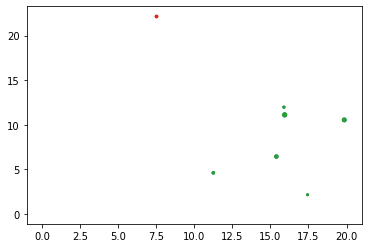

In [ ]:

def draw():
  #fig, ax = plt.subplots(figsize=(20, 20), subplot_kw={"projection":"3d"})
  site_list = []
  box_list = []
  pth = []

  with open('output_fix.txt', mode='r') as output:
      lines = output.readlines()
      index = 0
      xs = []
      ys = []
      zs = []
      
      while index < len(lines):
          n,m,d = map(int, lines[index].split())
          index += 1
          for i in range(n):
              coord = list(map(float, lines[index+i].split()))
              site_list.append(coord)
              xs.append(coord[0])
              ys.append(coord[1])
              zs.append(coord[2])
          index += n
          for i in range(m):
              box = []
              for j in range(2):
                  coord = list(map(int, lines[index+j].split()))
                  xs.append(float(coord[0]))
                  ys.append(float(coord[1]))
                  zs.append(float(coord[2]))
                  box.append(coord)
              box_list.append(box)
              index += 2
          query = list(map(float,lines[index].split()))
          xs.append(query[0])
          ys.append(query[1])
          zs.append(query[2])
          index += 1
          l = int(lines[index])
          index += 1
          for i in range(l):
              coord = list(map(float, lines[index+i].split()))
              xs.append(coord[0])
              ys.append(coord[1])
              zs.append(coord[2])
              pth.append(coord)
          index += l
  X=np.array([0,max(xs)])
  Y=np.array([0,max(ys)])
  Z=np.array([0,max(zs)])
  plt.plot(X,Y,Z,color='None')
  x_list, y_list, z_list = zip(*site_list)
  ax.scatter(x_list,y_list,z_list)
  ax.scatter(query[0],query[1],query[2])

  for box in box_list:
      boxx = [box[0][0],box[1][0],box[1][0],box[0][0],box[0][0],box[0][0],box[1][0],box[1][0],box[1][0],box[1][0],box[1][0],box[1][0],box[0][0],box[0][0],box[0][0],box[0][0],box[0][0]]
      boxy = [box[0][1],box[0][1],box[1][1],box[1][1],box[0][1],box[0][1],box[0][1],box[0][1],box[0][1],box[1][1],box[1][1],box[1][1],box[1][1],box[1][1],box[1][1],box[0][1],box[0][1]]
      boxz = [box[0][2],box[0][2],box[0][2],box[0][2],box[0][2],box[1][2],box[1][2],box[0][2],box[1][2],box[1][2],box[0][2],box[1][2],box[1][2],box[0][2],box[1][2],box[1][2],box[0][2]]
      ax.plot(boxx,boxy,boxz)
  xss,yss,zss = zip(*pth)
  ax.plot(xss,yss,zss)
  # Hide grid lines
  ax.grid(False)
  return fig,
# Hide axes ticks
#ax.set_xticks([])
#ax.set_yticks([])
#ax.set_zticks([])

def animate(frame):
    print(f"ANIMATE [frame {frame}]", end="\r")
    ax.view_init(elev=30., azim=frame)
    return fig,

site_list = []
box_list = []
pth = []
anim = animation.FuncAnimation(fig, animate, init_func=draw, frames=range(0, 360), interval=500, blit=True)
anim.save('output_fix.gif', fps=20)